# Data Parallelism & FSDP in JAX

## Scaling Training Across Devices with shard_map

**Scenario**: A genomics lab trains a classifier to predict **drug response categories** (sensitive, resistant, partial, toxic, non-responder) from high-dimensional **gene expression profiles**. The model and data are too large for a single device, so we need to distribute training across multiple devices.

We implement two complementary distribution strategies and verify they produce identical results:

| Strategy | Parameters | Data | Memory per Device | Communication |
|----------|-----------|------|-------------------|---------------|
| **Data Parallelism (DP)** | Replicated on all devices | Sharded across devices | Full model copy | `pmean` on gradients |
| **Fully-Sharded DP (FSDP)** | Sharded across devices | Sharded across devices | ~1/N model fraction | `all_gather` + `psum_scatter` |

FSDP reduces per-device memory by $\sim N\times$ (where $N$ = number of devices), enabling models that don't fit on a single device.

Based on the [UvA DLC Data Parallel & FSDP tutorial](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/scaling/JAX/data_parallel_fsdp.html).

---

## 1 — Device Setup

We simulate 8 CPU devices to demonstrate multi-device training without requiring actual GPUs/TPUs. The `XLA_FLAGS` environment variable must be set **before** importing JAX.

In [1]:
import os

N_DEVICES = 8
os.environ["XLA_FLAGS"] = f"--xla_force_host_platform_device_count={N_DEVICES}"
os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [ ]:
import functools
import warnings
from dataclasses import dataclass
from pprint import pprint
from typing import Any, Callable, Dict, Sequence, Tuple

import flax.linen as nn
import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import optax
from flax.training import train_state
from jax import lax, random
from ml_collections import ConfigDict
with warnings.catch_warnings():
    warnings.simplefilter("ignore", DeprecationWarning)
    from jax.experimental.shard_map import shard_map
from jax.sharding import Mesh
from jax.sharding import PartitionSpec as P

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

PyTree = Any
Metrics = Dict[str, Tuple[jax.Array, ...]]
Parameter = jax.Array | nn.Partitioned

print(f"JAX version: {jax.__version__}")
print(f"Devices: {jax.devices()}")
print(f"Device count: {jax.device_count()}")

---

## 2 — Dataset: Gene Expression Profiles

We generate synthetic gene expression data for 1024 tumor samples. Each sample has a **784-dimensional** expression vector (simulating a gene panel). The task is to classify each tumor into one of **10 drug response categories**.

In [ ]:
@dataclass
class Batch:
    """Container for a mini-batch of data."""
    inputs: jax.Array
    labels: jax.Array

# Register as JAX pytree so eval_shape/jit/shard_map can trace through it
jax.tree_util.register_dataclass(Batch, data_fields=['inputs', 'labels'], meta_fields=[])


# --- Configuration ---
BATCH_SIZE = 128
N_CLASSES = 10
INPUT_SIZE = 784
HIDDEN_SIZE = 512
SEED = 42

RESPONSE_NAMES = [
    "Sensitive", "Resistant", "Partial", "Toxic", "Non-responder",
    "Delayed", "Synergistic", "Antagonistic", "Adaptive", "Hypersensitive",
]

# --- Generate synthetic gene expression data ---
rng = random.PRNGKey(SEED)
model_init_rng, data_inputs_rng, data_labels_rng = random.split(rng, 3)

batch = Batch(
    inputs=random.normal(data_inputs_rng, (BATCH_SIZE, INPUT_SIZE)),
    labels=random.randint(data_labels_rng, (BATCH_SIZE,), 0, N_CLASSES),
)

print(f"Batch: {BATCH_SIZE} tumor samples × {INPUT_SIZE} genes → {N_CLASSES} response classes")
print(f"Batch sharding: {BATCH_SIZE} total ÷ {N_DEVICES} devices = {BATCH_SIZE // N_DEVICES} samples/device")

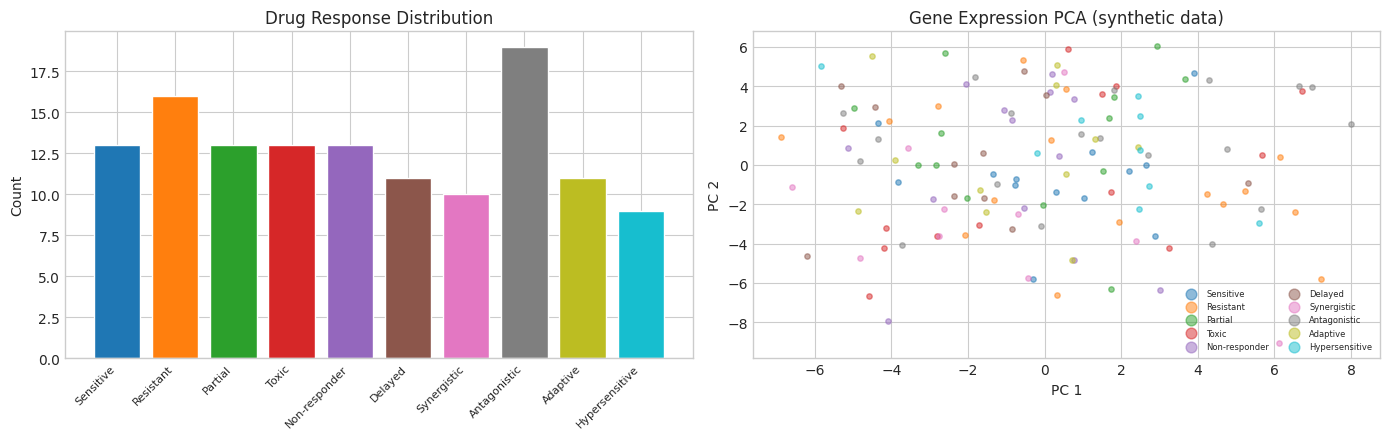

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

colors = plt.cm.tab10(np.linspace(0, 1, N_CLASSES))

# Class distribution
counts = [int((batch.labels == i).sum()) for i in range(N_CLASSES)]
axes[0].bar(range(N_CLASSES), counts, color=colors, edgecolor="white")
axes[0].set_xticks(range(N_CLASSES))
axes[0].set_xticklabels(RESPONSE_NAMES, rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("Count")
axes[0].set_title("Drug Response Distribution")

# 2D PCA projection of gene expression
X_centered = batch.inputs - batch.inputs.mean(axis=0)
U, S, Vt = jnp.linalg.svd(X_centered, full_matrices=False)
X_proj = X_centered @ Vt[:2].T

for i in range(N_CLASSES):
    mask = batch.labels == i
    axes[1].scatter(X_proj[mask, 0], X_proj[mask, 1], alpha=0.5, s=15,
                    color=colors[i], label=RESPONSE_NAMES[i])
axes[1].set_xlabel("PC 1")
axes[1].set_ylabel("PC 2")
axes[1].set_title("Gene Expression PCA (synthetic data)")
axes[1].legend(fontsize=6, markerscale=2, ncol=2)

plt.tight_layout()
plt.show()

---

## 3 — Core Utilities

Self-contained training infrastructure: `TrainState`, gradient accumulation via `jax.lax.scan`, and metric helpers. These are shared by both DP and FSDP training loops.

In [5]:
class TrainState(train_state.TrainState):
    """Flax TrainState extended with a PRNG key for dropout."""
    rng: jax.Array


def accumulate_gradients(
    state: TrainState,
    batch: Batch,
    rng: jax.Array,
    num_minibatches: int,
    loss_fn: Callable,
) -> Tuple[PyTree, Metrics]:
    """Accumulate gradients over mini-batches using jax.lax.scan."""
    batch_size = batch.inputs.shape[0]
    minibatch_size = batch_size // num_minibatches
    rngs = random.split(rng, num_minibatches)
    grad_fn = jax.value_and_grad(loss_fn, has_aux=True)

    def _minibatch_step(minibatch_idx):
        minibatch = Batch(
            inputs=lax.dynamic_slice_in_dim(
                batch.inputs, minibatch_idx * minibatch_size, minibatch_size, axis=0
            ),
            labels=lax.dynamic_slice_in_dim(
                batch.labels, minibatch_idx * minibatch_size, minibatch_size, axis=0
            ),
        )
        (_, step_metrics), step_grads = grad_fn(
            state.params, state.apply_fn, minibatch, rngs[minibatch_idx]
        )
        return step_grads, step_metrics

    def _scan_step(carry, minibatch_idx):
        step_grads, step_metrics = _minibatch_step(minibatch_idx)
        carry = jax.tree.map(jnp.add, carry, (step_grads, step_metrics))
        return carry, None

    # Initialize accumulators with zeros
    grads_shapes, metrics_shapes = jax.eval_shape(_minibatch_step, 0)
    init_grads = jax.tree.map(lambda x: jnp.zeros(x.shape, x.dtype), grads_shapes)
    init_metrics = jax.tree.map(lambda x: jnp.zeros(x.shape, x.dtype), metrics_shapes)

    (grads, metrics), _ = lax.scan(
        _scan_step,
        init=(init_grads, init_metrics),
        xs=jnp.arange(num_minibatches),
        length=num_minibatches,
    )
    grads = jax.tree.map(lambda g: g / num_minibatches, grads)
    return grads, metrics


def print_metrics(metrics: Metrics, title: str | None = None) -> None:
    """Print averaged metrics."""
    metrics = jax.device_get(metrics)
    if title:
        print(f"  {title}")
    for key, (total, count) in metrics.items():
        print(f"    {key}: {total / count:.4f}")


print("Core utilities ready.")

Core utilities ready.


---

## 4 — Device Mesh

A **mesh** maps physical devices to named logical axes. We create a 1D mesh with a single `"data"` axis — batch samples are distributed along this axis.

```
Device 0  Device 1  Device 2  ...  Device 7
├─ 16 ──┤├─ 16 ──┤├─ 16 ──┤      ├─ 16 ──┤  (128 total samples)
         └──────── data axis ────────────┘
```

In [6]:
DATA_AXIS_NAME = "data"

device_array = np.array(jax.devices())
mesh = Mesh(device_array, (DATA_AXIS_NAME,))

print(f"Mesh: {mesh.shape}")
print(f"Axis '{DATA_AXIS_NAME}': {mesh.shape[DATA_AXIS_NAME]} devices")
print(f"Samples per device: {BATCH_SIZE // mesh.shape[DATA_AXIS_NAME]}")

Mesh: OrderedDict({'data': 8})
Axis 'data': 8 devices
Samples per device: 16


---

## 5 — Configuration

Shared configuration for both DP and FSDP models.

In [ ]:
data_config = ConfigDict(
    dict(
        batch_size=BATCH_SIZE,
        num_classes=N_CLASSES,
        input_size=INPUT_SIZE,
    )
)

model_config = ConfigDict(
    dict(
        hidden_size=HIDDEN_SIZE,
        dropout_rate=0.1,
        dtype=jnp.bfloat16,
        num_classes=data_config.num_classes,
        data_axis_name=DATA_AXIS_NAME,
    )
)

optimizer_config = ConfigDict(
    dict(
        learning_rate=1e-3,
        num_minibatches=4,
    )
)

config = ConfigDict(
    dict(
        model=model_config,
        optimizer=optimizer_config,
        data=data_config,
        data_axis_name=DATA_AXIS_NAME,
        seed=SEED,
    )
)

print("Config:")
print(f"  Model: {HIDDEN_SIZE} hidden, bfloat16, dropout={model_config.dropout_rate}")
print(f"  Optimizer: AdamW, lr={optimizer_config.learning_rate}")
print(f"  Gradient accumulation: {optimizer_config.num_minibatches} minibatches")

---

## 6 — Data Parallelism (DP)

In standard data parallelism, each device holds a **full copy** of the model parameters and processes a **different slice** of the batch. After computing gradients locally, devices synchronize via `pmean`:

$$\bar{g} = \frac{1}{N} \sum_{i=1}^{N} g_i \quad \text{(all-reduce mean)}$$

### 6.1 — Model

A simple two-layer MLP with bfloat16 activations:

In [8]:
class DPClassifier(nn.Module):
    """Data-parallel drug response classifier."""
    config: Any

    @nn.compact
    def __call__(self, x: jax.Array, train: bool) -> jax.Array:
        x = nn.Dense(
            features=self.config.hidden_size,
            dtype=self.config.dtype,
            name="input_dense",
        )(x)
        x = nn.silu(x)
        x = nn.Dropout(rate=self.config.dropout_rate, deterministic=not train)(x)
        x = nn.Dense(
            features=self.config.num_classes,
            dtype=self.config.dtype,
            name="output_dense",
        )(x)
        x = x.astype(jnp.float32)
        return x


model_dp = DPClassifier(config=config.model)
optimizer = optax.adamw(learning_rate=config.optimizer.learning_rate)

print(f"DP model: {INPUT_SIZE} → {HIDDEN_SIZE} → {N_CLASSES}")
print(f"Activation dtype: bfloat16, output cast to float32")

DP model: 784 → 512 → 10
Activation dtype: bfloat16, output cast to float32


### 6.2 — Dropout RNG Folding

Since each device processes different data, they need **different dropout masks**. We fold the RNG key over the data axis so each device derives a unique key from its axis index:

In [9]:
def fold_rng_over_axis(rng: jax.random.PRNGKey, axis_name: str) -> jax.random.PRNGKey:
    """Fold RNG over a named axis so each device gets a unique key."""
    axis_index = lax.axis_index(axis_name)
    return random.fold_in(rng, axis_index)

### 6.3 — Loss Function

Standard cross-entropy loss with per-device dropout folding. Each device computes loss on its local batch shard:

In [10]:
def loss_fn(
    params: PyTree, apply_fn: Any, batch: Batch, rng: jax.Array
) -> Tuple[jax.Array, Metrics]:
    """Cross-entropy loss with per-device dropout."""
    dropout_rng = fold_rng_over_axis(rng, config.data_axis_name)
    logits = apply_fn(
        {"params": params}, batch.inputs, train=True,
        rngs={"dropout": dropout_rng},
    )
    loss = optax.softmax_cross_entropy_with_integer_labels(logits, batch.labels)
    correct_pred = jnp.equal(jnp.argmax(logits, axis=-1), batch.labels)
    batch_size = batch.inputs.shape[0]
    step_metrics = {
        "loss": (loss.sum(), batch_size),
        "accuracy": (correct_pred.sum(), batch_size),
    }
    return loss.mean(), step_metrics

### 6.4 — Initialization with shard_map

`shard_map` lets us write code for a **single device** and have it automatically execute across all devices in the mesh. For initialization:
- **Input RNG**: replicated (`P()`) — same init on all devices
- **Input data**: sharded (`P("data")`) — each device sees its slice
- **Output state**: replicated (`P()`) — full model copy on each device

In [11]:
def init_dp(rng: jax.random.PRNGKey, x: jax.Array, model: nn.Module) -> TrainState:
    """Initialize model parameters and optimizer state."""
    init_rng, rng = random.split(rng)
    variables = model.init({"params": init_rng}, x, train=False)
    params = variables.pop("params")
    state = TrainState.create(
        apply_fn=model.apply,
        params=params,
        tx=optimizer,
        rng=rng,
    )
    return state


init_dp_fn = jax.jit(
    shard_map(
        functools.partial(init_dp, model=model_dp),
        mesh,
        in_specs=(P(), P(config.data_axis_name)),
        out_specs=P(),
        check_rep=False,
    ),
)

state_dp = init_dp_fn(model_init_rng, batch.inputs)

print("DP Parameters (replicated on all devices):")
pprint(jax.tree.map(lambda x: (x.shape, x.sharding), state_dp.params))

DP Parameters (replicated on all devices):
{'input_dense': {'bias': ((512,),
                          NamedSharding(mesh=Mesh('data': 8, axis_types=(Auto,)), spec=PartitionSpec(), memory_kind=device)),
                 'kernel': ((784, 512),
                            NamedSharding(mesh=Mesh('data': 8, axis_types=(Auto,)), spec=PartitionSpec(), memory_kind=device))},
 'output_dense': {'bias': ((10,),
                           NamedSharding(mesh=Mesh('data': 8, axis_types=(Auto,)), spec=PartitionSpec(), memory_kind=device)),
                  'kernel': ((512, 10),
                             NamedSharding(mesh=Mesh('data': 8, axis_types=(Auto,)), spec=PartitionSpec(), memory_kind=device))}}


### 6.5 — DP Training Step

Each device:
1. Computes gradients on its local batch shard (with gradient accumulation)
2. Averages gradients across all devices via `pmean`
3. Applies the same optimizer update → parameters stay synchronized

In [12]:
def train_step_dp(
    state: TrainState,
    metrics: Metrics | None,
    batch: Batch,
) -> Tuple[TrainState, Metrics]:
    """DP training step: local gradients → pmean → update."""
    rng, step_rng = random.split(state.rng)
    grads, step_metrics = accumulate_gradients(
        state, batch, step_rng,
        config.optimizer.num_minibatches,
        loss_fn=loss_fn,
    )
    # Synchronize gradients across all devices
    with jax.named_scope("sync_gradients"):
        grads = jax.tree.map(
            lambda g: lax.pmean(g, axis_name=config.data_axis_name), grads
        )
    new_state = state.apply_gradients(grads=grads, rng=rng)
    # Synchronize metrics
    with jax.named_scope("sync_metrics"):
        step_metrics = jax.tree.map(
            lambda x: lax.psum(x, axis_name=config.data_axis_name), step_metrics
        )
    if metrics is None:
        metrics = step_metrics
    else:
        metrics = jax.tree.map(jnp.add, metrics, step_metrics)
    return new_state, metrics


train_step_dp_fn = jax.jit(
    shard_map(
        train_step_dp,
        mesh,
        in_specs=(P(), P(), P(config.data_axis_name)),
        out_specs=(P(), P()),
        check_rep=False,
    ),
    donate_argnames=("state", "metrics"),
)

print("DP training step compiled.")

DP training step compiled.


### 6.6 — DP Training Loop

In [ ]:
# Initialize metrics accumulator
def _zero_metrics():
    return {"loss": (jnp.zeros(()), jnp.zeros(())), "accuracy": (jnp.zeros(()), jnp.zeros(()))}

metrics_dp = _zero_metrics()

# Warmup: 15 steps
for _ in range(15):
    state_dp, metrics_dp = train_step_dp_fn(state_dp, metrics_dp, batch)

# Final step with fresh metrics for reporting
state_dp, final_metrics_dp = train_step_dp_fn(state_dp, _zero_metrics(), batch)

print_metrics(final_metrics_dp, "DP — Final metrics")
print("\nDP Parameters (still replicated):")
pprint(jax.tree.map(lambda x: (x.shape, x.sharding), state_dp.params))

---

## 7 — Fully-Sharded Data Parallelism (FSDP)

Standard DP replicates the **entire model** on each device. For large models, this wastes memory. FSDP **shards parameters** across devices:

- Each device stores only $1/N$ of the parameters
- Before a layer's computation, parameters are **gathered** from all devices (`all_gather`)
- After computation, parameters are **re-sharded** to free memory
- Gradients use `psum_scatter` (the reverse of `all_gather`)

```
Standard DP:     Device 0: [Full W₁, Full W₂]    Device 1: [Full W₁, Full W₂]
FSDP:            Device 0: [W₁ shard 0, W₂ shard 0]  Device 1: [W₁ shard 1, W₂ shard 1]
                          ↕ all_gather before use ↕
```

### 7.1 — Shard Parameters

Split each parameter along its **largest divisible dimension**. Small parameters (below `min_weight_size`) stay replicated — the communication cost of gathering them would exceed the memory savings.

In [ ]:
@jax.named_scope("shard_params")
def shard_params(params: PyTree, axis_name: str, min_weight_size: int = 2**18) -> PyTree:
    """Shard parameters across the given mesh axis.

    Each parameter is split along its largest dimension that is divisible
    by the axis size. Parameters smaller than min_weight_size are kept replicated.
    """
    axis_idx = lax.axis_index(axis_name)
    axis_size = lax.psum(1, axis_name)

    def _split(x: Parameter) -> Parameter:
        if isinstance(x, nn.Partitioned):
            value, names = x.value, x.names
        else:
            value = x
            names = (None,) * value.ndim
        if axis_name in names:
            return x  # Already sharded on this axis
        elif value.size <= min_weight_size:
            return x  # Too small to benefit from sharding
        else:
            shape = value.shape
            idx = np.argsort(shape)[::-1]  # Try largest dimension first
            for i in idx:
                if shape[i] % axis_size == 0 and names[i] is None:
                    split_size = shape[i] // axis_size
                    return nn.Partitioned(
                        value=lax.dynamic_slice_in_dim(
                            value, axis_idx * split_size, split_size, axis=i
                        ),
                        names=names[:i] + (axis_name,) + names[i + 1:],
                    )
            return x  # No suitable axis found

    return jax.tree_util.tree_map(
        _split, params,
        is_leaf=lambda x: isinstance(x, nn.Partitioned),
    )

### 7.2 — Gather Parameters

Before each layer's forward pass, reconstruct the full parameter from shards using `all_gather`. The custom gradient ensures that during backprop, gradients flow correctly via `psum_scatter`:

$$\text{Forward: } W = \text{all\_gather}(W_{\text{shard}}) \qquad \text{Backward: } \nabla W_{\text{shard}} = \text{psum\_scatter}(\nabla W) / N$$

In [ ]:
def gather_array_with_mean_grads(x: jax.Array, axis: int, axis_name: str):
    """All-gather with averaged gradients via psum_scatter in backward pass."""
    axis_size = lax.psum(1, axis_name)

    @jax.custom_gradient
    def f(x):
        def grad_fn(g):
            return (
                lax.psum_scatter(g, axis_name, scatter_dimension=axis, tiled=True)
                / axis_size
            )
        return lax.all_gather(x, axis_name, axis=axis, tiled=True), grad_fn

    return f(x)


@jax.named_scope("gather_params")
def gather_params(params: PyTree, axis_name: str) -> PyTree:
    """Gather sharded parameters from all devices."""

    def _gather(p: Parameter) -> Parameter:
        if isinstance(p, nn.Partitioned) and axis_name in p.names:
            param_shard = p.names
            shard_axis = param_shard.index(axis_name)
            value = gather_array_with_mean_grads(
                p.value, axis=shard_axis, axis_name=axis_name
            )
            param_shard = param_shard[:shard_axis] + (None,) + param_shard[shard_axis + 1:]
            if any(name is not None for name in param_shard):
                return nn.Partitioned(value, param_shard)
            else:
                return value
        else:
            return p

    return jax.tree_util.tree_map(
        _gather, params,
        is_leaf=lambda x: isinstance(x, nn.Partitioned),
    )

### 7.3 — Shard Module Parameters

Flax's `nn.map_variables` wraps a module so that:
- **Before** the module runs: `gather_params` reconstructs full parameters from shards
- **After** the module runs: `shard_params` re-shards the parameters

This is transparent to the module itself — it sees full parameters during computation.

In [ ]:
def shard_module_params(
    target: nn.Module | Callable,
    axis_name: str,
    min_weight_size: int = 2**18,
) -> nn.Module | Callable:
    """Wrap a module to automatically gather/shard parameters around computation."""
    return nn.map_variables(
        target,
        trans_in_fn=functools.partial(gather_params, axis_name=axis_name),
        trans_out_fn=functools.partial(
            shard_params, axis_name=axis_name, min_weight_size=min_weight_size
        ),
        mapped_collections="params",
        mutable=True,
    )

### 7.4 — FSDP Classifier

Same architecture as DP, but Dense layers are wrapped with `shard_module_params`:

In [ ]:
class FSDPClassifier(nn.Module):
    """FSDP drug response classifier with sharded Dense layers."""
    config: Any

    @nn.compact
    def __call__(self, x: jax.Array, train: bool) -> jax.Array:
        sharded_dense = shard_module_params(
            nn.Dense,
            axis_name=self.config.data_axis_name,
            min_weight_size=self.config.min_weight_size,
        )
        x = sharded_dense(
            features=self.config.hidden_size,
            dtype=self.config.dtype,
            name="input_dense",
        )(x)
        x = nn.silu(x)
        x = nn.Dropout(rate=self.config.dropout_rate, deterministic=not train)(x)
        x = sharded_dense(
            features=self.config.num_classes,
            dtype=self.config.dtype,
            name="output_dense",
        )(x)
        x = x.astype(jnp.float32)
        return x


# Use low threshold so our small model actually gets sharded
config.model.min_weight_size = 2**4
model_fsdp = FSDPClassifier(config=config.model)

print(f"FSDP model: same architecture, min_weight_size={config.model.min_weight_size}")
print(f"Parameters will be sharded across {N_DEVICES} devices")

### 7.5 — FSDP Initialization

We first evaluate the shapes to determine the partition spec (which axes each parameter is sharded along), then JIT-compile with the correct `out_specs`:

In [ ]:
# Step 1: Evaluate shapes to get partition specs
init_fsdp_fn_shapes = shard_map(
    functools.partial(init_dp, model=model_fsdp),
    mesh,
    in_specs=(P(), P(config.data_axis_name)),
    out_specs=P(),
    check_rep=False,
)
state_fsdp_shapes = jax.eval_shape(init_fsdp_fn_shapes, model_init_rng, batch.inputs)
state_fsdp_specs = nn.get_partition_spec(state_fsdp_shapes)

print("FSDP Partition Specs:")
print("\n  Parameters:")
pprint(state_fsdp_specs.params)
print("\n  Optimizer state (first group):")
pprint(state_fsdp_specs.opt_state[0])

In [ ]:
# Step 2: JIT-compile with correct output partition specs
init_fsdp_fn = jax.jit(
    shard_map(
        functools.partial(init_dp, model=model_fsdp),
        mesh,
        in_specs=(P(), P(config.data_axis_name)),
        out_specs=state_fsdp_specs,
        check_rep=False,
    )
)

state_fsdp = init_fsdp_fn(model_init_rng, batch.inputs)

print("FSDP Parameters (sharded across devices):")
pprint(jax.tree.map(lambda x: x.shape, jax.device_get(state_fsdp.params)))

### 7.6 — Gradient Synchronization

In FSDP, parameters have **mixed sharding** — some are sharded, some are replicated (too small to shard). We need a smarter gradient sync:

- **Replicated params**: average gradients with `pmean` (same as DP)
- **Sharded params**: gradients are already correctly distributed via `psum_scatter` in the custom backward pass — no additional sync needed

In [ ]:
def sync_gradients(
    grads: PyTree,
    axis_names: Sequence[str],
) -> PyTree:
    """Synchronize gradients: pmean for replicated, pass-through for sharded."""

    def sync_grad(g: Parameter) -> Parameter:
        if isinstance(g, nn.Partitioned):
            replication_axis_names = [
                name for name in axis_names
                if name not in jax.tree_util.tree_leaves(g.names)
            ]
            if len(replication_axis_names) == 0:
                return g  # Fully sharded — no sync needed
            else:
                return g.replace(
                    value=lax.pmean(g.value, axis_name=replication_axis_names)
                )
        else:
            return lax.pmean(g, axis_name=axis_names)  # Fully replicated

    return jax.tree.map(
        sync_grad, grads,
        is_leaf=lambda x: isinstance(x, nn.Partitioned),
    )

### 7.7 — FSDP Training Step & Loop

In [ ]:
def train_step_fsdp(
    state: TrainState,
    metrics: Metrics | None,
    batch: Batch,
) -> Tuple[TrainState, Metrics]:
    """FSDP training step: local grads → smart sync → update."""
    rng, step_rng = random.split(state.rng)
    grads, step_metrics = accumulate_gradients(
        state, batch, step_rng,
        config.optimizer.num_minibatches,
        loss_fn=loss_fn,
    )
    with jax.named_scope("sync_gradients"):
        grads = sync_gradients(grads, (config.data_axis_name,))
    new_state = state.apply_gradients(grads=grads, rng=rng)
    with jax.named_scope("sync_metrics"):
        step_metrics = jax.tree.map(
            lambda x: lax.psum(x, axis_name=config.data_axis_name), step_metrics
        )
    if metrics is None:
        metrics = step_metrics
    else:
        metrics = jax.tree.map(jnp.add, metrics, step_metrics)
    return new_state, metrics


train_step_fsdp_fn = jax.jit(
    shard_map(
        train_step_fsdp,
        mesh,
        in_specs=(state_fsdp_specs, P(), P(config.data_axis_name)),
        out_specs=(state_fsdp_specs, P()),
        check_rep=False,
    ),
    donate_argnames=("state", "metrics"),
)

print("FSDP training step compiled.")

In [ ]:
# Initialize FSDP metrics and train
metrics_fsdp = _zero_metrics()

# Warmup: 15 steps
for _ in range(15):
    state_fsdp, metrics_fsdp = train_step_fsdp_fn(state_fsdp, metrics_fsdp, batch)

# Final step with fresh metrics
state_fsdp, final_metrics_fsdp = train_step_fsdp_fn(
    state_fsdp, _zero_metrics(), batch
)

print_metrics(final_metrics_fsdp, "FSDP — Final metrics")

---

## 8 — Verification: DP vs FSDP

A critical correctness check: DP and FSDP must produce **identical** results since they're mathematically equivalent — they just distribute computation differently.

In [ ]:
# Compare metrics
metrics_dp_host = jax.device_get(final_metrics_dp)
metrics_fsdp_host = jax.device_get(final_metrics_fsdp)

print("Metric comparison (DP vs FSDP):")
print(f"{'Metric':<12} {'DP':>10} {'FSDP':>10} {'Match':>8}")
print("-" * 42)
for key in metrics_dp_host:
    val_dp = metrics_dp_host[key][0] / metrics_dp_host[key][1]
    val_fsdp = metrics_fsdp_host[key][0] / metrics_fsdp_host[key][1]
    match = np.allclose(val_dp, val_fsdp, atol=1e-2)
    print(f"{key:<12} {val_dp:>10.4f} {val_fsdp:>10.4f} {'OK' if match else 'FAIL':>8}")
    np.testing.assert_allclose(val_dp, val_fsdp, atol=1e-2)

In [ ]:
# Compare parameters (unwrap nn.Partitioned for FSDP)
params_dp = jax.device_get({"params": state_dp.params, "opt_state": state_dp.opt_state})
params_fsdp = jax.device_get({"params": state_fsdp.params, "opt_state": state_fsdp.opt_state})
params_fsdp = jax.tree.map(
    lambda x: x.value if isinstance(x, nn.Partitioned) else x,
    params_fsdp,
    is_leaf=lambda x: isinstance(x, nn.Partitioned),
)

_ = jax.tree.map(
    lambda x, y: np.testing.assert_allclose(x, y, atol=1e-4),
    params_dp, params_fsdp,
)
print("All parameters match between DP and FSDP (atol=1e-4)")

---

## 9 — Visualizing the Sharding

Let's visualize how parameters and data are distributed across devices in both strategies.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

colors_dp = ["#6366f1"] * N_DEVICES
colors_fsdp = plt.cm.Set2(np.linspace(0, 1, N_DEVICES))

# --- Panel 1: Data sharding (same for both) ---
samples_per_device = BATCH_SIZE // N_DEVICES
for i in range(N_DEVICES):
    axes[0].barh(
        f"Device {i}", samples_per_device,
        left=i * samples_per_device,
        color=colors_fsdp[i], edgecolor="white", height=0.6,
    )
axes[0].set_xlabel("Batch samples")
axes[0].set_title("Data Sharding (both DP & FSDP)")
axes[0].set_xlim(0, BATCH_SIZE)

# --- Panel 2: Parameter layout (DP = replicated) ---
layer_names = [(path, leaf.shape) for path, leaf in jax.tree_util.tree_leaves_with_path(state_dp.params)]
param_labels = []
param_sizes = []
for path, shape in layer_names:
    name = "/".join(str(k.key) for k in path)
    size = np.prod(shape)
    param_labels.append(f"{name}\n{shape}")
    param_sizes.append(size)

x_pos = np.arange(len(param_labels))
for i in range(N_DEVICES):
    axes[1].bar(
        x_pos, param_sizes,
        bottom=[0] * len(param_sizes),
        color="#6366f1", alpha=0.15 + 0.1 * (i % 2),
        edgecolor="white", width=0.7,
    )
axes[1].bar(x_pos, param_sizes, color="#6366f1", edgecolor="white", width=0.7, alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(param_labels, fontsize=7, rotation=30, ha="right")
axes[1].set_ylabel("Parameter count")
axes[1].set_title("DP: Full copy on each device")

# --- Panel 3: Parameter layout (FSDP = sharded) ---
fsdp_params = jax.device_get(state_fsdp.params)
fsdp_leaves = list(jax.tree_util.tree_leaves_with_path(
    fsdp_params, is_leaf=lambda x: isinstance(x, nn.Partitioned)
))

fsdp_labels = []
fsdp_sizes_per_device = []
fsdp_is_sharded = []
for path, leaf in fsdp_leaves:
    name = "/".join(str(k.key) for k in path)
    if isinstance(leaf, nn.Partitioned):
        shape = leaf.value.shape
        fsdp_is_sharded.append(True)
    else:
        shape = leaf.shape
        fsdp_is_sharded.append(False)
    fsdp_labels.append(f"{name}\n{shape}")
    fsdp_sizes_per_device.append(np.prod(shape))

x_pos_f = np.arange(len(fsdp_labels))
bar_colors = ["#10b981" if s else "#6366f1" for s in fsdp_is_sharded]
axes[2].bar(x_pos_f, fsdp_sizes_per_device, color=bar_colors, edgecolor="white", width=0.7)
axes[2].set_xticks(x_pos_f)
axes[2].set_xticklabels(fsdp_labels, fontsize=7, rotation=30, ha="right")
axes[2].set_ylabel("Params per device")
axes[2].set_title("FSDP: Sharded across devices")

# Legend for sharded vs replicated
from matplotlib.patches import Patch
axes[2].legend(
    handles=[
        Patch(facecolor="#10b981", label="Sharded (1/N per device)"),
        Patch(facecolor="#6366f1", label="Replicated (too small to shard)"),
    ],
    fontsize=8, loc="upper right",
)

plt.tight_layout()
plt.show()

---

## 10 — Memory Comparison

Estimate per-device parameter memory for each strategy:

In [ ]:
# Compute actual parameter sizes
dp_total = sum(np.prod(x.shape) for x in jax.tree.leaves(state_dp.params))

fsdp_per_device = 0
fsdp_full = 0
for leaf in jax.tree_util.tree_leaves(
    jax.device_get(state_fsdp.params),
    is_leaf=lambda x: isinstance(x, nn.Partitioned),
):
    if isinstance(leaf, nn.Partitioned):
        fsdp_per_device += np.prod(leaf.value.shape)
        shard_axis = leaf.names.index(DATA_AXIS_NAME)
        full_shape = list(leaf.value.shape)
        full_shape[shard_axis] *= N_DEVICES
        fsdp_full += np.prod(full_shape)
    else:
        fsdp_per_device += np.prod(leaf.shape)
        fsdp_full += np.prod(leaf.shape)

# Memory in bytes (float32 params)
bytes_per_param = 4
dp_memory = dp_total * bytes_per_param
fsdp_memory = fsdp_per_device * bytes_per_param

print(f"{'Strategy':<10} {'Params/device':>15} {'Memory/device':>15} {'Reduction':>10}")
print("-" * 55)
print(f"{'DP':<10} {dp_total:>15,} {dp_memory / 1024:>12.1f} KB {'1.0×':>10}")
print(f"{'FSDP':<10} {fsdp_per_device:>15,} {fsdp_memory / 1024:>12.1f} KB {dp_memory / fsdp_memory:>9.1f}×")
print(f"\nFSDP stores {fsdp_per_device / dp_total:.1%} of the full model per device")

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3.5))

strategies = ["Data Parallel (DP)", "Fully-Sharded DP (FSDP)"]
memories = [dp_memory / 1024, fsdp_memory / 1024]
bar_colors = ["#6366f1", "#10b981"]

bars = ax.barh(strategies, memories, color=bar_colors, edgecolor="white", height=0.5)
for bar, m in zip(bars, memories):
    ax.text(
        bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
        f"{m:.1f} KB", va="center", fontsize=10,
    )

ax.set_xlabel("Parameter Memory per Device (KB)")
ax.set_title("Per-Device Memory: DP vs FSDP")
plt.tight_layout()
plt.show()

---

## 11 — Communication Patterns

Understanding the communication cost of each strategy:

| Operation | DP | FSDP |
|-----------|----|----- |
| **Forward pass** | None | `all_gather` per layer ($O(P)$ data) |
| **Backward pass** | `all_reduce` on gradients ($O(P)$ data) | `psum_scatter` per layer ($O(P)$ data) |
| **Total communication** | $O(P)$ | $O(2P)$ per layer |
| **Memory per device** | $O(P)$ | $O(P/N)$ |

Where $P$ = total parameters, $N$ = number of devices.

FSDP trades **2× more communication** for **$N\times$ less memory**. For large models where memory is the bottleneck, this trade-off is clearly worthwhile.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Communication volume scaling with model size
model_sizes = np.array([1e6, 10e6, 100e6, 1e9, 10e9])
labels_sizes = ["1M", "10M", "100M", "1B", "10B"]

dp_comm = model_sizes * 4 / 1e9  # all-reduce: one pass of P, float32
fsdp_comm = model_sizes * 4 * 2 / 1e9  # 2 passes: all_gather + psum_scatter

axes[0].plot(range(len(model_sizes)), dp_comm, 'o-', color="#6366f1",
             label="DP (all-reduce)", linewidth=2, markersize=8)
axes[0].plot(range(len(model_sizes)), fsdp_comm, 's-', color="#10b981",
             label="FSDP (gather + scatter)", linewidth=2, markersize=8)
axes[0].set_xticks(range(len(model_sizes)))
axes[0].set_xticklabels(labels_sizes)
axes[0].set_xlabel("Model Size (parameters)")
axes[0].set_ylabel("Communication Volume (GB)")
axes[0].set_title("Communication Cost")
axes[0].set_yscale("log")
axes[0].legend(fontsize=9)

# Memory per device scaling
n_devices_range = np.array([1, 2, 4, 8, 16, 32, 64])
model_size_example = 1e9  # 1B parameters
mem_bytes = model_size_example * 4  # float32

dp_mem = np.full_like(n_devices_range, mem_bytes / 1e9, dtype=float)
fsdp_mem = mem_bytes / n_devices_range / 1e9

axes[1].plot(n_devices_range, dp_mem, 'o-', color="#6366f1",
             label="DP", linewidth=2, markersize=8)
axes[1].plot(n_devices_range, fsdp_mem, 's-', color="#10b981",
             label="FSDP", linewidth=2, markersize=8)
axes[1].axhline(y=16, color="#ef4444", linestyle="--", alpha=0.5, label="16 GB GPU limit")
axes[1].set_xlabel("Number of Devices")
axes[1].set_ylabel("Param Memory per Device (GB)")
axes[1].set_title("Memory Scaling (1B param model)")
axes[1].set_xscale("log", base=2)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---

## Summary

We implemented two distribution strategies for training a drug response classifier on gene expression data across 8 simulated devices:

| Component | Data Parallelism | FSDP |
|-----------|-----------------|------|
| **Parameters** | Replicated (full copy per device) | Sharded (1/N per device) |
| **Data** | Sharded across batch dim | Sharded across batch dim |
| **Forward** | Local compute | `all_gather` → compute → re-shard |
| **Gradient sync** | `pmean` (all-reduce) | `psum_scatter` for sharded, `pmean` for replicated |
| **Memory** | $O(P)$ per device | $O(P/N)$ per device |
| **Use case** | Model fits on one device | Model too large for one device |

**Key takeaways**:

- `shard_map` lets you write **single-device code** that automatically parallelizes across a mesh
- **DP** is simpler — just `pmean` the gradients after each step
- **FSDP** enables training models $N\times$ larger by sharding parameters, at the cost of 2× more communication
- `nn.Partitioned` tracks which axis each parameter is sharded on, enabling correct gradient synchronization
- Both strategies produce **identical results** — verified by comparing metrics and parameters within numerical tolerance